In [8]:
import pandas as pd 
import torch 
import numpy 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict

In [9]:
human_eval = pd.read_csv('logged_entropy/humanevak.csv')
gradesm = pd.read_csv("logged_entropy/gsm8k.csv")
sharegpt = pd.read_csv('logged_entropy/sharegpt.csv')
arc = pd.read_csv('logged_entropy/arc_challenge.csv')
litbench = pd.read_csv('logged_entropy/litbench_train.csv')

In [10]:
human_eval.head()

,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,entropy_smoothed_w16,entropy_smoothed_w32,accepted_text
0,0,0,149,3,4,3,"(0, 0, 0)","(0, 0, 0, 1)",1.970996,1.970996,1.970996,1.970996,Here's the
1,0,1,153,3,4,3,"(2, 0, 0)","(2, 0, 0)",1.200216,1.530550,1.573174,1.579489,completed function:\n
2,0,2,157,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",0.110084,0.916295,1.053686,1.074057,```python\nfrom typing
3,0,3,162,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",0.000171,0.581255,0.764289,0.792668,import List\n\ndef
4,0,4,167,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",0.001193,0.391119,0.591363,0.624165,has_close_elements


MACD style features

In [11]:
import ast
dataframes = {'human_eval': human_eval,
              'gsm8k':      gradesm,
              'sharegpt':   sharegpt, 
              'arc':        arc,
              'litbench':   litbench}

transformed = defaultdict(dict)

for dataset, df in dataframes.items():
    macd_df = df.copy()

    macd_df['macd_4_16']  = macd_df['entropy_smoothed_w4']  - macd_df['entropy_smoothed_w16']
    macd_df['macd_4_32']  = macd_df['entropy_smoothed_w4']  - macd_df['entropy_smoothed_w32']
    macd_df['macd_16_32'] = macd_df['entropy_smoothed_w16'] - macd_df['entropy_smoothed_w32']

    macd_df['macd_1_4']  = macd_df['block_start_entropy'] - macd_df['entropy_smoothed_w4']
    macd_df['macd_1_16'] = macd_df['block_start_entropy'] - macd_df['entropy_smoothed_w16']
    macd_df['macd_1_32'] = macd_df['block_start_entropy'] - macd_df['entropy_smoothed_w32']
    
    for col in ['macd_4_16', 'macd_4_32', 'macd_16_32',
                'macd_1_4',  'macd_1_16', 'macd_1_32']:
        macd_df[f'{col}_signal'] = macd_df.groupby('sample_idx')[col].transform(
            lambda x: x.ewm(span=4, adjust=False).mean()
        )
        macd_df[f'{col}_hist'] = macd_df[col] - macd_df[f'{col}_signal']

    macd_df['entropy_delta'] = macd_df.groupby('sample_idx')['block_start_entropy'].diff()

    g = macd_df.groupby('sample_idx')['accept_length']
    macd_df['prev_accept']         = g.shift(1)
    macd_df['prev_2_accept']       = g.shift(2)
    macd_df['prev_3_accept']       = g.shift(3)
    macd_df['prev_3_accept_avg']   = g.shift(1).rolling(3, min_periods=1).mean()
    macd_df['prev_5_accept_avg']   = g.shift(1).rolling(5, min_periods=1).mean()
    macd_df['prev_5_accept_max']   = g.shift(1).rolling(5, min_periods=1).max()
    macd_df['prev_5_accept_min']   = g.shift(1).rolling(5, min_periods=1).min()
    macd_df['prev_accept_ema']     = g.shift(1).transform(
        lambda x: x.ewm(span=8, adjust=False).mean()
    )
    macd_df['accept_momentum'] = macd_df['prev_accept'] - macd_df['prev_3_accept_avg']

    transformed[dataset]['raw'] = macd_df

    print(f"\ndataset: {dataset}")
    display(macd_df.head(3))


dataset: human_eval


,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,...,entropy_delta,prev_accept,prev_2_accept,prev_3_accept,prev_3_accept_avg,prev_5_accept_avg,prev_5_accept_max,prev_5_accept_min,prev_accept_ema,accept_momentum
0,0,0,149,3,4,3,"(0, 0, 0)","(0, 0, 0, 1)",1.970996,1.970996,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,153,3,4,3,"(2, 0, 0)","(2, 0, 0)",1.200216,1.530550,...,-0.770780,3.0,NaN,NaN,3.0,3.0,3.0,3.0,3.0,0.0
2,0,2,157,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",0.110084,0.916295,...,-1.090132,3.0,3.0,NaN,3.0,3.0,3.0,3.0,3.0,0.0



dataset: gsm8k


,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,...,entropy_delta,prev_accept,prev_2_accept,prev_3_accept,prev_3_accept_avg,prev_5_accept_avg,prev_5_accept_max,prev_5_accept_min,prev_accept_ema,accept_momentum
0,0,0,133,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",1.639900,1.639900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,138,4,5,4,"(0, 0, 0, 1)","(0, 0, 0, 1)",0.190881,0.811889,...,-1.44902,4.0,NaN,NaN,4.0,4.0,4.0,4.0,4.0,0.0
2,0,2,143,2,3,2,"(1, 1)","(1, 1)",0.101551,0.504716,...,-0.08933,4.0,4.0,NaN,4.0,4.0,4.0,4.0,4.0,0.0



dataset: sharegpt


,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,...,entropy_delta,prev_accept,prev_2_accept,prev_3_accept,prev_3_accept_avg,prev_5_accept_avg,prev_5_accept_max,prev_5_accept_min,prev_accept_ema,accept_momentum
0,0,0,42,2,3,2,"(0, 0)","(0, 0, 0, 1)",1.181144,1.181144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,45,2,3,2,"(0, 0)","(0, 0, 0, 1)",1.024941,1.091885,...,-0.156204,2.0,NaN,NaN,2.0,2.0,2.0,2.0,2.0,0.0
2,0,2,48,2,3,2,"(4, 0)","(4, 0)",3.244577,2.022779,...,2.219637,2.0,2.0,NaN,2.0,2.0,2.0,2.0,2.0,0.0



dataset: arc


,sample_idx,step,position,generated_so_far,accept_length,tokens_this_step,block_start_entropy,block_start_entropy_delta,prev_accept_length,prev_accept_is_one,...,entropy_delta,prev_accept,prev_2_accept,prev_3_accept,prev_3_accept_avg,prev_5_accept_avg,prev_5_accept_max,prev_5_accept_min,prev_accept_ema,accept_momentum
0,0,0,117,0,3,4,1.386300,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,121,4,3,4,0.285477,-1.100823,3.0,0.0,...,-1.100823,3.0,NaN,NaN,3.0,3.0,3.0,3.0,3.0,0.0
2,0,2,125,8,3,4,0.000891,-0.284586,3.0,0.0,...,-0.284586,3.0,3.0,NaN,3.0,3.0,3.0,3.0,3.0,0.0



dataset: litbench


,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,...,entropy_delta,prev_accept,prev_2_accept,prev_3_accept,prev_3_accept_avg,prev_5_accept_avg,prev_5_accept_max,prev_5_accept_min,prev_accept_ema,accept_momentum
0,0,0,90,1,2,1,"(0,)","(0, 0, 0, 1)",3.179112,3.179112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,92,3,4,3,"(0, 4, 0)","(0, 4, 0)",2.979973,3.065318,...,-0.199140,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.000000,0.0
2,0,2,96,2,3,2,"(3, 1)","(3, 1)",2.502838,2.822083,...,-0.477135,3.0,1.0,NaN,2.0,2.0,3.0,1.0,1.444444,1.0


In [12]:
feature_cols = [
    'block_start_entropy',
    'entropy_smoothed_w4', 'entropy_smoothed_w16', 'entropy_smoothed_w32',
    'macd_4_16',        'macd_4_32',        'macd_16_32',
    'macd_4_16_signal', 'macd_4_32_signal', 'macd_16_32_signal',
    'macd_4_16_hist',   'macd_4_32_hist',   'macd_16_32_hist',
    'macd_1_4',         'macd_1_16',        'macd_1_32',
    'macd_1_4_signal',  'macd_1_16_signal', 'macd_1_32_signal',
    'macd_1_4_hist',    'macd_1_16_hist',   'macd_1_32_hist',
    'entropy_delta',
]
target_col = 'accept_length'

for dataset, dfs in transformed.items():
    data = dfs['raw']
    clean = data[feature_cols + [target_col]].dropna()
    X = torch.tensor(clean[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(clean[target_col].to_numpy(), dtype=torch.float32)
    X_c = X - X.mean(dim=0)
    y_c = y - y.mean()
    pearson = (X_c * y_c.unsqueeze(1)).mean(0) / (X_c.std(0) * y_c.std() + 1e-8)

    pearson_df = pd.DataFrame({
        'feature': feature_cols,
        'pearson_r': pearson.detach().cpu().tolist()
    }).sort_values('pearson_r', key=abs, ascending=False)

    print(f'dataset type: {dataset}')
    top3 = pearson_df['feature'].head(7).tolist()
    print(top3)

    display(pearson_df.head(7))
    
    dfs['pearson'] = pearson_df
    dfs['top_features'] = top3


dataset type: human_eval
['macd_1_4_signal', 'macd_1_32', 'macd_1_16', 'block_start_entropy', 'macd_4_32_hist', 'macd_4_16_hist', 'macd_1_4']


,feature,pearson_r
16,macd_1_4_signal,-0.160639
15,macd_1_32,-0.159961
14,macd_1_16,-0.158343
0,block_start_entropy,-0.156509
11,macd_4_32_hist,-0.149958
10,macd_4_16_hist,-0.148539
13,macd_1_4,-0.148496


dataset type: gsm8k
['entropy_smoothed_w4', 'entropy_smoothed_w16', 'entropy_smoothed_w32', 'block_start_entropy', 'macd_4_32_hist', 'macd_16_32_hist', 'macd_1_32']


,feature,pearson_r
1,entropy_smoothed_w4,-0.193170
2,entropy_smoothed_w16,-0.182408
3,entropy_smoothed_w32,-0.178480
0,block_start_entropy,-0.175349
11,macd_4_32_hist,-0.103053
12,macd_16_32_hist,-0.102837
15,macd_1_32,-0.102086


dataset type: sharegpt
['block_start_entropy', 'entropy_smoothed_w4', 'entropy_smoothed_w16', 'entropy_smoothed_w32', 'macd_1_32', 'macd_1_16', 'macd_16_32_hist']


,feature,pearson_r
0,block_start_entropy,-0.185342
1,entropy_smoothed_w4,-0.162552
2,entropy_smoothed_w16,-0.146207
3,entropy_smoothed_w32,-0.143592
15,macd_1_32,-0.108926
14,macd_1_16,-0.108626
12,macd_16_32_hist,-0.108458


dataset type: arc
['block_start_entropy', 'entropy_smoothed_w4', 'macd_1_16_signal', 'macd_1_32_signal', 'macd_1_32', 'macd_1_16', 'entropy_smoothed_w16']


,feature,pearson_r
0,block_start_entropy,-0.166971
1,entropy_smoothed_w4,-0.158247
17,macd_1_16_signal,-0.133348
18,macd_1_32_signal,-0.131091
15,macd_1_32,-0.130430
14,macd_1_16,-0.128971
2,entropy_smoothed_w16,-0.128647


dataset type: litbench
['entropy_smoothed_w4', 'block_start_entropy', 'entropy_smoothed_w16', 'entropy_smoothed_w32', 'macd_4_32_hist', 'macd_4_16_hist', 'macd_16_32_hist']


,feature,pearson_r
1,entropy_smoothed_w4,-0.189728
0,block_start_entropy,-0.178971
2,entropy_smoothed_w16,-0.175623
3,entropy_smoothed_w32,-0.172658
11,macd_4_32_hist,-0.088329
10,macd_4_16_hist,-0.087612
12,macd_16_32_hist,-0.082901


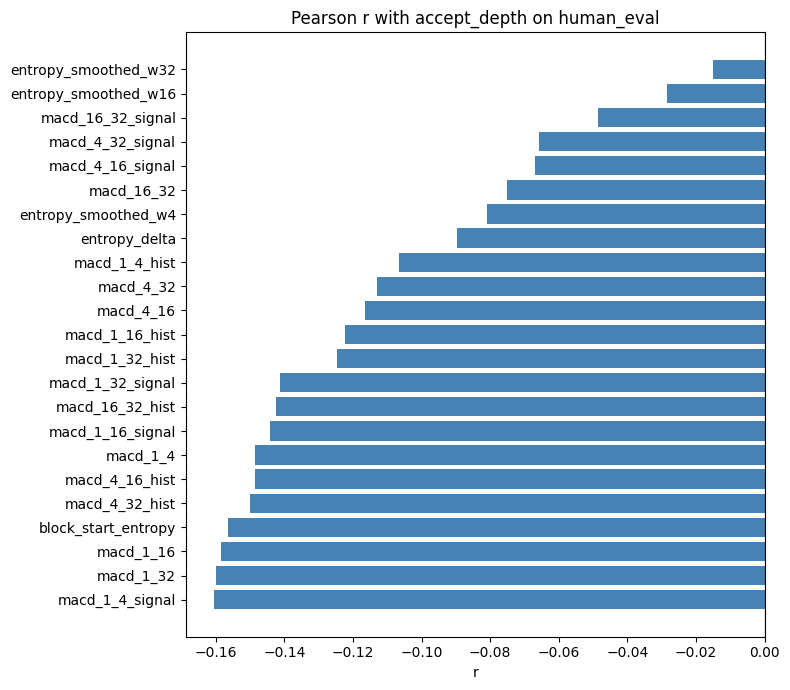

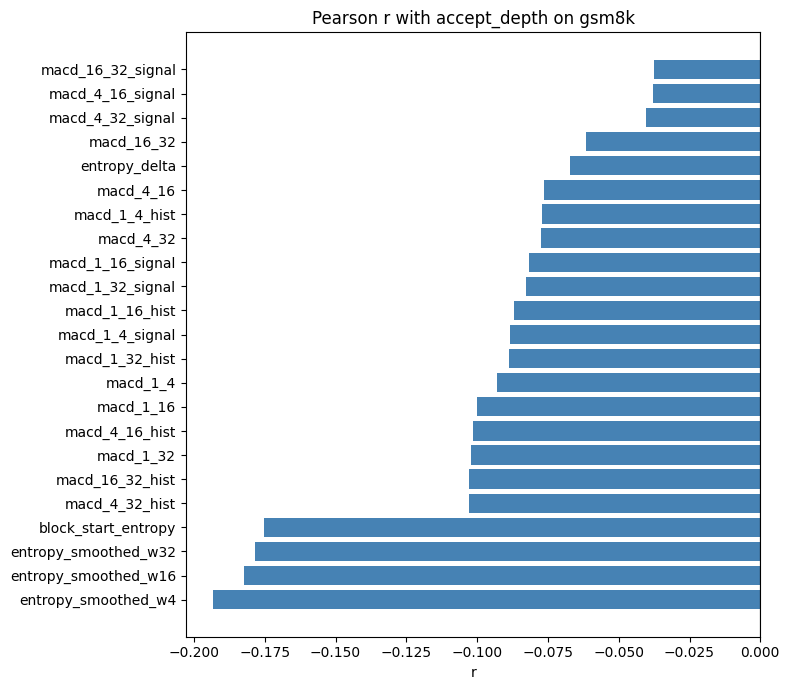

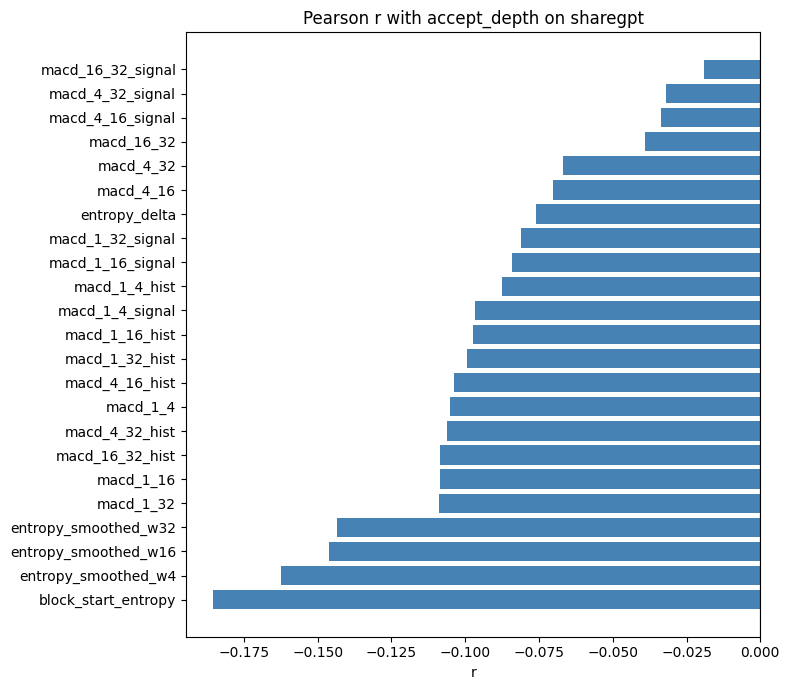

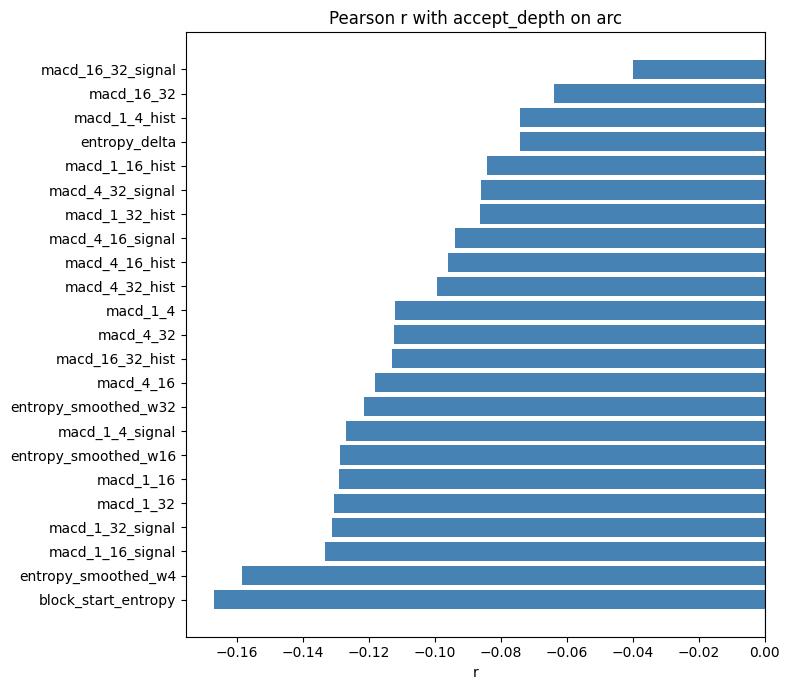

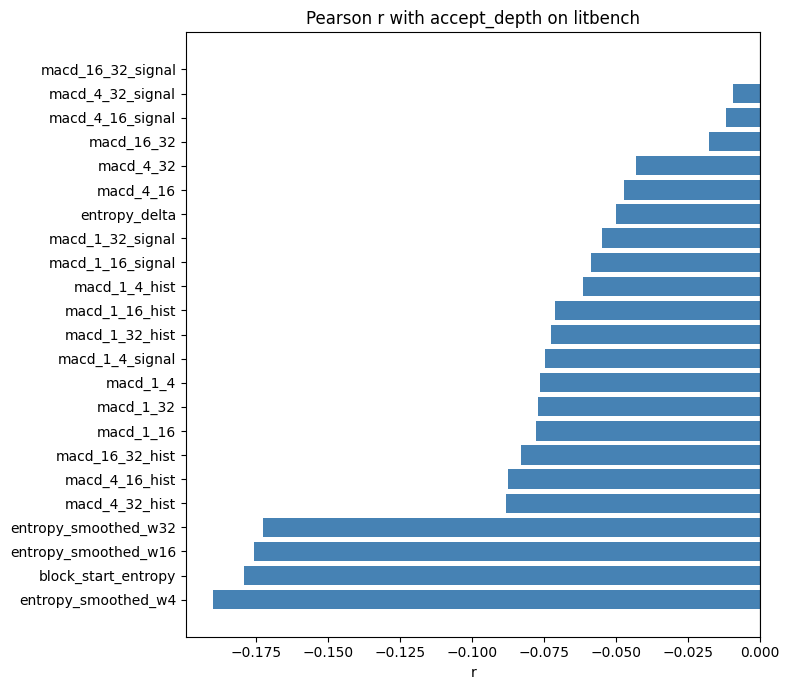

In [13]:
for dataset, dfs in transformed.items():
    pearson_df = dfs['pearson']
    fig, ax = plt.subplots(figsize=(8, 7))
    colors = ['tomato' if v > 0 else 'steelblue' for v in pearson_df['pearson_r']]
    ax.barh(pearson_df['feature'], pearson_df['pearson_r'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Pearson r with accept_depth on {dataset}')
    ax.set_xlabel('r')
    plt.tight_layout()
    plt.show()

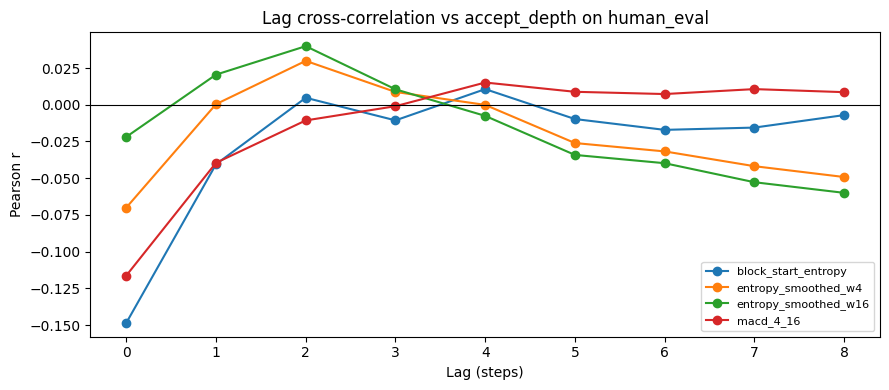

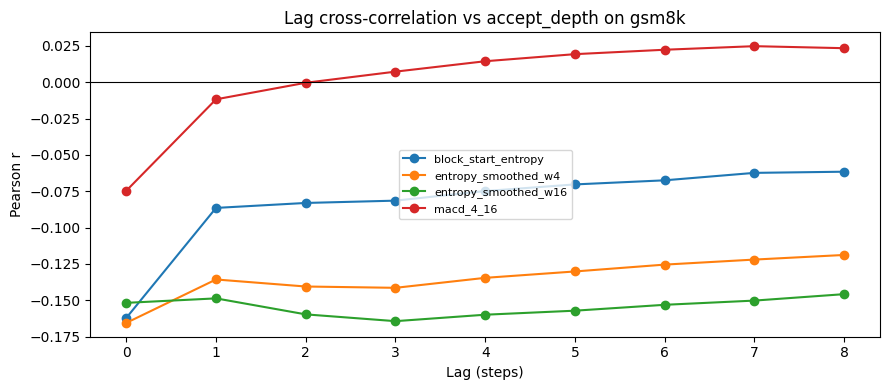

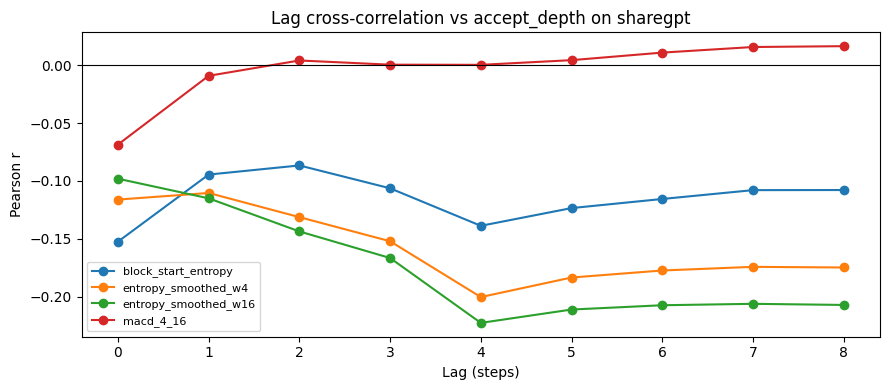

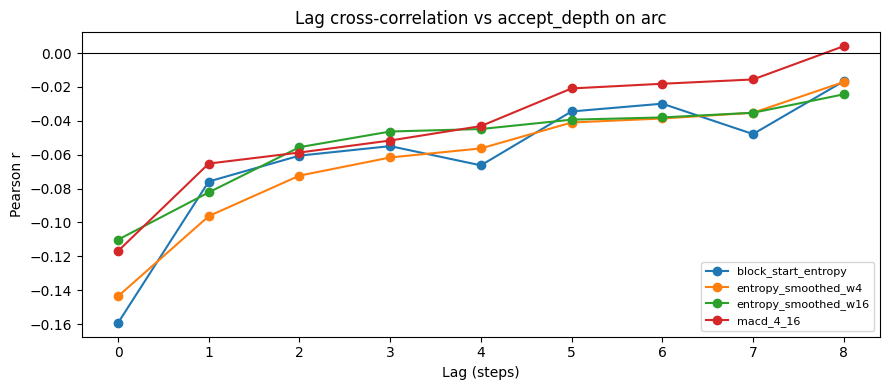

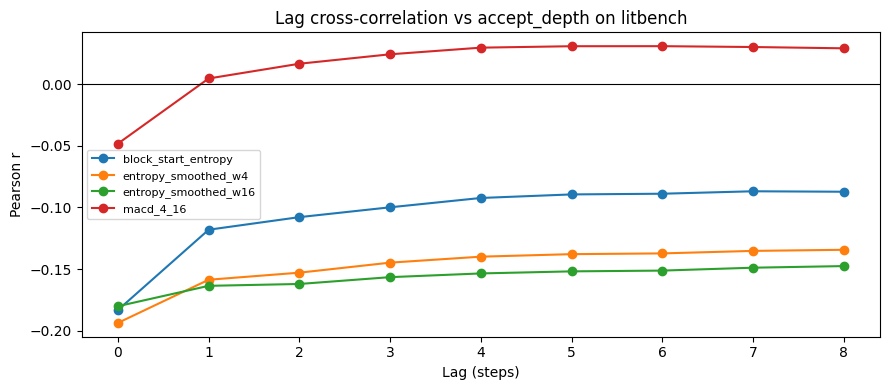

In [14]:
max_lag = 8
lag_feats = ['block_start_entropy', 'entropy_smoothed_w4',
             'entropy_smoothed_w16', 'macd_4_16']

for datasets, dfs in transformed.items():
    macd_df = dfs['raw']
    lag_results = {}
    for feat in lag_feats:
        rows = []
        for lag in range(0, max_lag + 1):
            shifted = macd_df.groupby('sample_idx')[feat].shift(lag)
            valid   = macd_df[[target_col]].join(shifted.rename('s')).dropna()
            r, p    = stats.pearsonr(valid['s'], valid[target_col])
            rows.append({'lag': lag, 'r': r, 'p': p})
        lag_results[feat] = pd.DataFrame(rows)

    # plot
    fig, ax = plt.subplots(figsize=(9, 4))
    for feat, res in lag_results.items():
        ax.plot(res['lag'], res['r'], marker='o', label=feat)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Lag cross-correlation vs accept_depth on {datasets}')
    ax.set_xlabel('Lag (steps)')
    ax.set_ylabel('Pearson r')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    lag_results['block_start_entropy']

    dfs['lagged'] = lag_results

/tmp/ipykernel_383209/1357628730.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


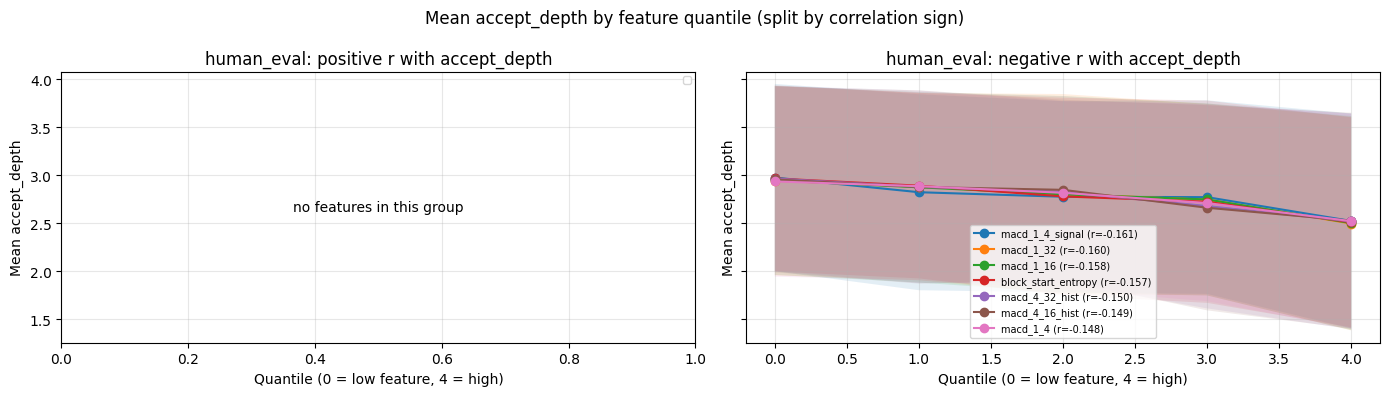

/tmp/ipykernel_383209/1357628730.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


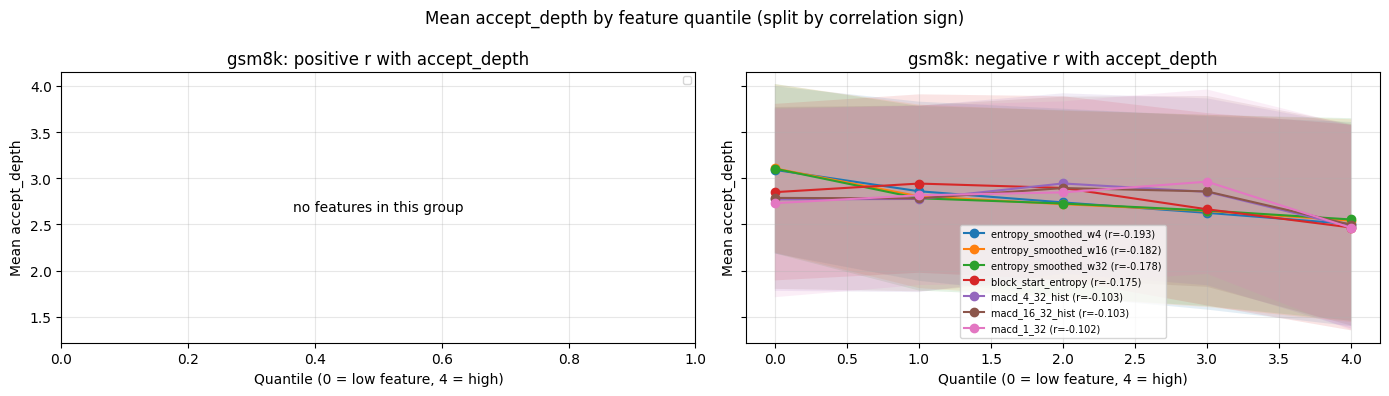

/tmp/ipykernel_383209/1357628730.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


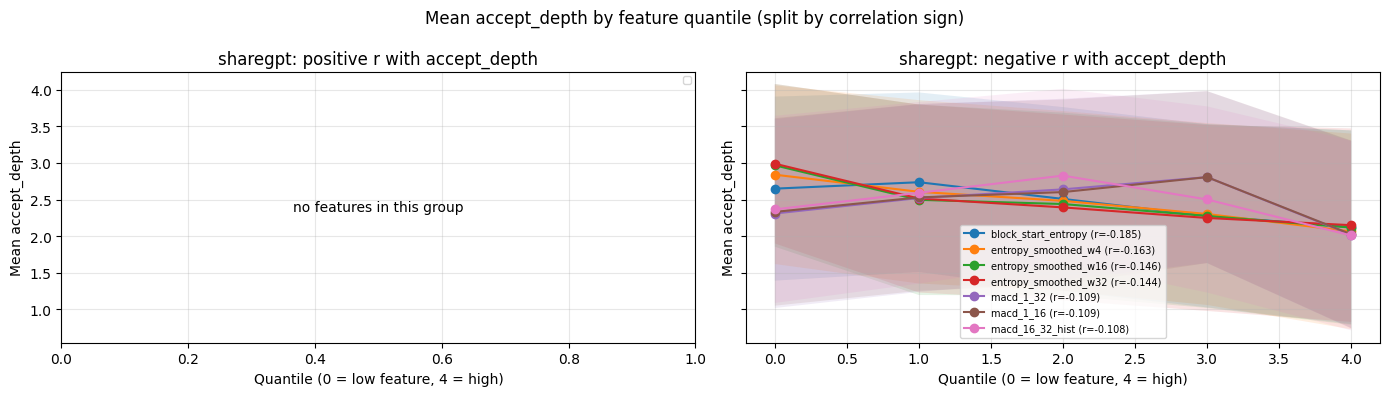

/tmp/ipykernel_383209/1357628730.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


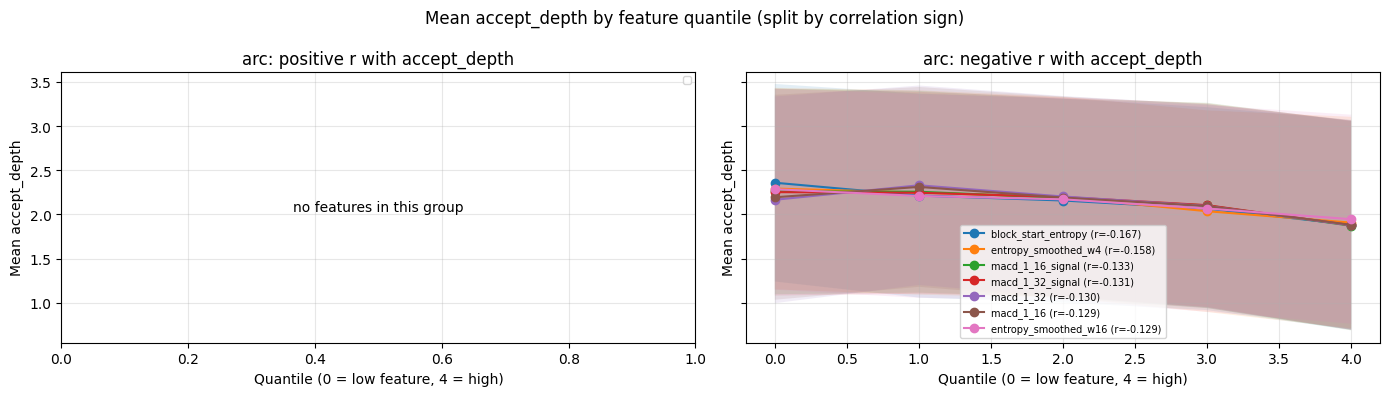

/tmp/ipykernel_383209/1357628730.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


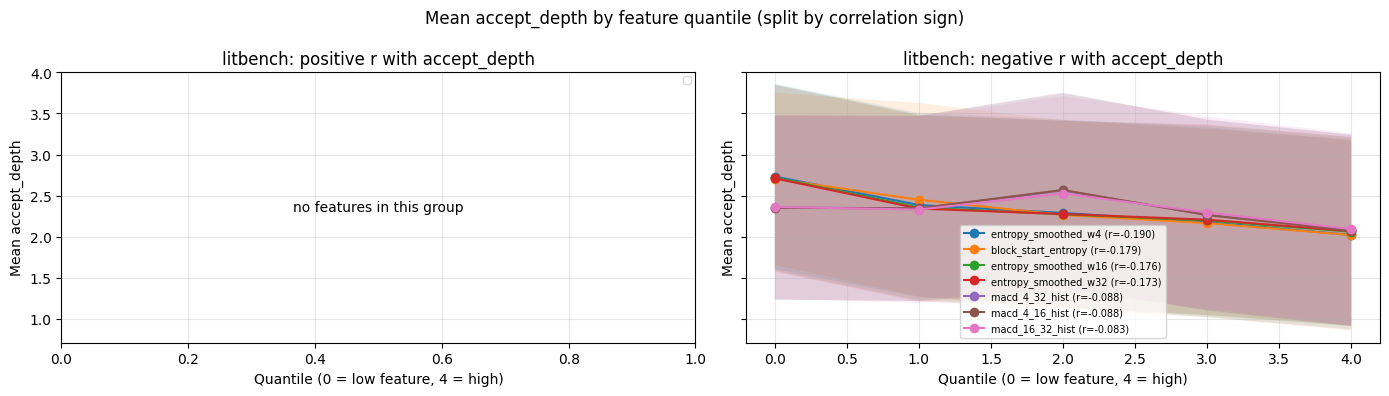

In [15]:

for dataset, dfs in transformed.items():
    macd_df = dfs['raw']
    bucket_feats = dfs['top_features']
    pearson_df = dfs.get('pearson')
    if pearson_df is not None:
        r_map = pearson_df.set_index('feature')['pearson_r'].to_dict()
    else:
        r_map = {}
        for feat in bucket_feats:
            sub = macd_df[[feat, target_col]].dropna()
            r_map[feat] = float(sub[feat].corr(sub[target_col])) if len(sub) >= 3 else 0.0

    pos_feats = [f for f in bucket_feats if r_map.get(f, 0.0) > 0]
    neg_feats = [f for f in bucket_feats if r_map.get(f, 0.0) < 0]
    zero_feats = [f for f in bucket_feats if r_map.get(f, 0.0) == 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    last_bkt = {}
    for ax, feats, title_suffix in [
        (axes[0], pos_feats, 'positive r with accept_depth'),
        (axes[1], neg_feats, 'negative r with accept_depth'),
    ]:
        if not feats:
            ax.text(0.5, 0.5, 'no features in this group', ha='center', va='center', transform=ax.transAxes)
        for feat in feats:
            tmp = macd_df[[feat, target_col]].dropna().copy()
            tmp['q'] = pd.qcut(tmp[feat], q=5, labels=False, duplicates='drop')
            bkt = tmp.groupby('q')[target_col].agg(['mean', 'std'])
            last_bkt[feat] = bkt
            r = r_map.get(feat, float('nan'))
            ax.plot(bkt.index, bkt['mean'], marker='o', label=f'{feat} (r={r:.3f})')
            ax.fill_between(
                bkt.index,
                bkt['mean'] - bkt['std'],
                bkt['mean'] + bkt['std'],
                alpha=0.12,
            )
        ax.set_title(f'{dataset}: {title_suffix}')
        ax.set_xlabel('Quantile (0 = low feature, 4 = high)')
        ax.set_ylabel('Mean accept_depth')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        'Mean accept_depth by feature quantile (split by correlation sign)'
        + (f'  |  r=0 (omitted): {zero_feats}' if zero_feats else '')
    )
    plt.tight_layout()
    plt.show()
    dfs['buckets_plot'] = last_bkt
    dfs['buckets_plot_split'] = {
        'pos_feats': pos_feats,
        'neg_feats': neg_feats,
        'zero_feats': zero_feats,
        'r_map': r_map,
    }


Entropy macd histograms on human_eval


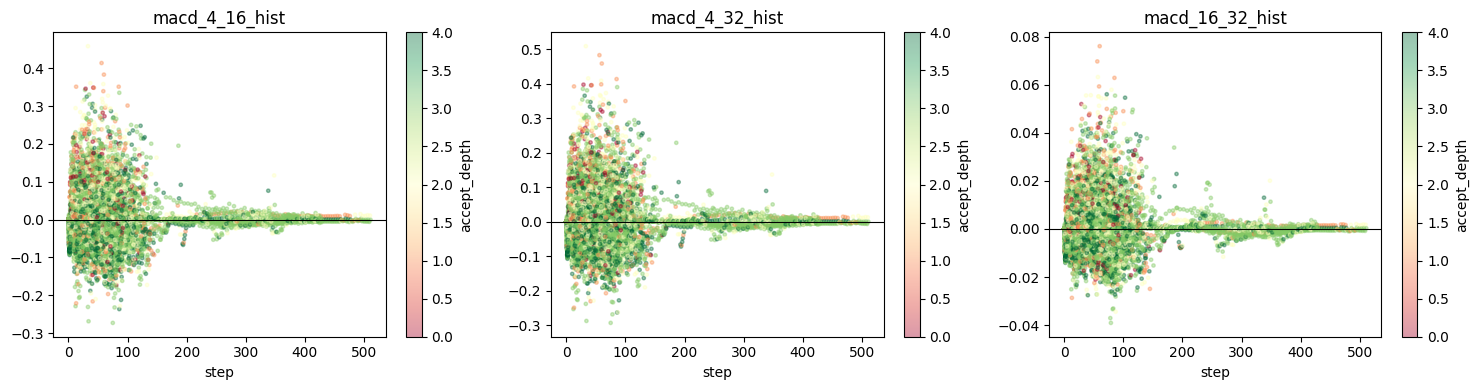

Entropy macd histograms on gsm8k


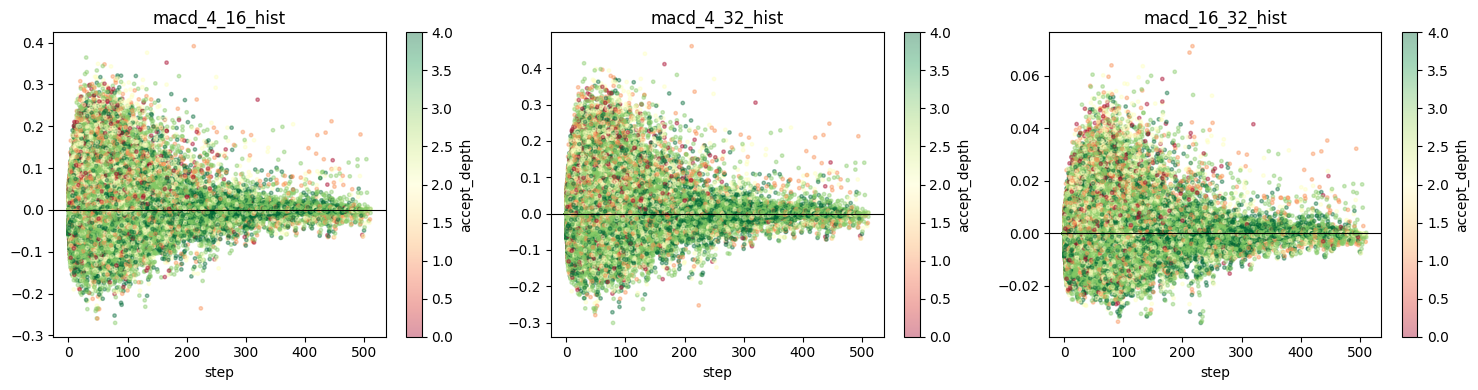

Entropy macd histograms on sharegpt


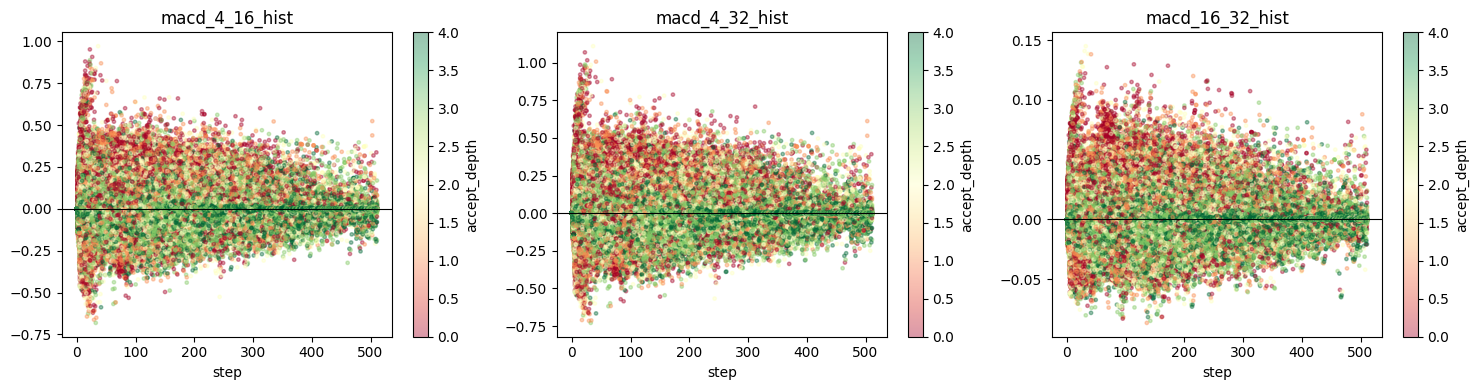

KeyError: 'accept_depth'

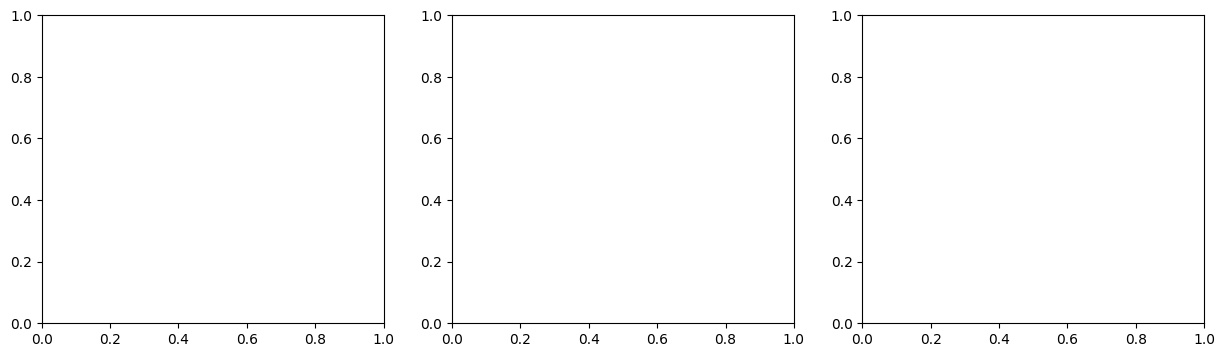

In [16]:
for dataset, dfs in transformed.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    macd_df = dfs['raw']
    for ax, col in zip(axes, ['macd_4_16_hist', 'macd_4_32_hist', 'macd_16_32_hist']):
        sc = ax.scatter(macd_df['step'], macd_df[col],
                        c=macd_df['accept_depth'], cmap='RdYlGn', alpha=0.4, s=6)
        plt.colorbar(sc, ax=ax, label='accept_depth')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(col)
        ax.set_xlabel('step')
        
    print(f'Entropy macd histograms on {dataset}')
    plt.tight_layout()
    plt.show()

In [ ]:
heat_cols = [
    'block_start_entropy',
    'entropy_smoothed_w4', 'entropy_smoothed_w16', 'entropy_smoothed_w32',
    'macd_4_16', 'macd_4_32', 'macd_16_32',
    'macd_4_16_hist', 'macd_4_32_hist', 'macd_16_32_hist',
    'macd_1_4', 'macd_1_16', 'macd_1_32',
    'macd_1_4_signal', 'macd_1_16_signal', 'macd_1_32_signal',
    'macd_1_4_hist', 'macd_1_16_hist', 'macd_1_32_hist',
    'accept_depth'
]

for dataset, dfs in transformed.items():
    macd_df = dfs['raw']
    top3 = dfs['top_features']
    corr = macd_df[heat_cols].dropna().corr()

    fig, axes = plt.subplots(1, 2, figsize=(22, 10))
    fig.suptitle(f'Feature correlation matrix — {dataset}', fontsize=13)

    sns.heatmap(
        corr,
        ax=axes[0], annot=True, fmt='.2f',
        cmap='coolwarm', center=0, square=True, annot_kws={'size': 7}
    )
    axes[0].set_title('All features')

    zoom_cols = top3 + ['block_start_entropy', 'macd_4_16_hist',
                        'macd_1_32', 'macd_1_4_signal', 'accept_depth']
    zoom_cols = list(dict.fromkeys(zoom_cols)) 
    sns.heatmap(
        macd_df[zoom_cols].dropna().corr(),
        ax=axes[1], annot=True, fmt='.2f',
        cmap='coolwarm', center=0, square=True, annot_kws={'size': 9}
    )
    axes[1].set_title(f'Top features zoom\n{top3}')

    plt.tight_layout()
    display(fig)
    plt.close(fig)